# Basics and introduction to the practice sessions

**Outline**

- [JupyterLab](https://jupyterlab.readthedocs.io/en/stable/index.html)
- [Atomic Simulation Environment (ASE)](https://ase-lib.org/#)

Before we continue with GPAW calculations, let us take a look at the [Atomic Simulation Environment (ASE)](https://ase-lib.org/#).

ASE is not only central to our practical sessions, but also usually the first choice for atomistic calculations.

**Disclaimer:** ASE is not always **the** best choice, but typically offers the lowest access barrier. It is well-suited for getting a workflow up and running and modular enough to leave room for refactoring.

## Features

- Python
- [open source](https://gitlab.com/ase/ase)
- [exhaustive documentation](https://ase-lib.org/about.html)
- [large selection of tutorials](https://ase-lib.org/examples_generated/index.html#)
- LLMs can usually help

## HowTo JupyterLab

The JupyterLab team provides useful [documentation](https://jupyterlab.readthedocs.io/en/latest/). Tutorials, videos and such are widely available on the net, but I would rather recommend getting the basics and consulting your search engine or LLM of choice to figure out what features you need for what you are trying to achieve.

In this workshop we use JupyterLab version 4.5.6, in case you want to look for specific information.

Here, we will simply go through the basics of the interface to get us started, nothing fancy.

As for everything else coming up, feel free to interrupt and ask.

**Some code cells throughout will be collapsed by default, so you can first try your own ideas. Those cells may contain a <font color="green">hint</font> or a <font color="red">solution</font>. Visible comments indicate what is hidden.**

## Atomic Simulation Environment (ASE)

### `ase.atoms.Atoms`

#### At the core of ASE sits the `Atoms` class. Accordingly, all structures are `Atoms` objects with set properties.

First, let us create an fcc copper bulk crystal with a cubic unit cell.

For this introduction, I will demonstrate the solutions directly, the following just as an example for the hands-on sessions.

In [1]:
# import the necessary package

cu_fcc = None

print(f"The fcc copper bulk crystal is {cu_fcc}.")

The fcc copper bulk crystal is None.


In [2]:
# hint - click to expand

# ASE provides the function `ase.build.bulk`
from ase.build import bulk

# You can also manually create the `ase.atoms.Atoms` object
from ase.atoms import Atoms


In [3]:
# solution - click to expand

from ase.build import bulk

a = 3.58

cu_fcc = bulk(
    name="Cu",
    crystalstructure="fcc",
    a=a,  # same lattice constant as used above
    cubic=True,  # to get the same result
)

In [4]:
# solution - click to expand

from ase.atoms import Atoms

a = b = c = 3.58

cu_fcc = Atoms("Cu4",
           positions=[
               [0.0, 0.0, 0.0],
               [0.0, 1.79, 1.79],
               [1.79, 0.0, 1.79],
               [1.79, 1.79, 0.0],
           ],
           cell=[
               [a, 0.0, 0.0],
               [0.0, b, 0.0],
               [0.0, 0.0, c],
           ]
          )

##### Another option is to load the suitable structure from [The Materials Project](https://next-gen.materialsproject.org/)

##### and read it from the disk

In [5]:
import pathlib
import ase.io  # will be discussed further down

# the pathlib package is incredibly useful for file operations
mp_file = pathlib.Path.cwd().parents[1] / "data/presentation/Cu.poscar"
cu_fcc_mp = ase.io.read(mp_file)

# show the file content
print(mp_file.read_text())

# Jupyter offers a number of "magic commands", for example
%pycat {pathlib.Path.cwd().parents[1] / "data/presentation/Cu.poscar"}

Cu4
1.0
   3.5774306715697510    0.0000000000000000    0.0000000000000002
   0.0000000000000006    3.5774306715697510    0.0000000000000002
   0.0000000000000000    0.0000000000000000    3.5774306715697510
Cu
4
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Cu0+
   0.0000000000000000    0.5000000000000000    0.5000000000000000 Cu0+
   0.5000000000000000    0.0000000000000000    0.5000000000000000 Cu0+
   0.5000000000000000    0.5000000000000000    0.0000000000000000 Cu0+



Cu4
1.0
   3.5774306715697510    0.0000000000000000    0.0000000000000002
   0.0000000000000006    3.5774306715697510    0.0000000000000002
   0.0000000000000000    0.0000000000000000    3.5774306715697510
Cu
4
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Cu0+
   0.0000000000000000    0.5000000000000000    0.5000000000000000 Cu0+
   0.5000000000000000    0.0000000000000000    0.5000000000000000 Cu0+
   0.5000000000000000    0.5000000000000000    0.0000000000000000 Cu0+


#### Properties and meta information


In [6]:
# some information is provided via `print()`
print(f"Cu from MP:\n{cu_fcc_mp}\n")

# other properties need to be accessed directly
print("Scaled positions:\n", cu_fcc_mp.get_scaled_positions())
print(f"\nThe Atoms object cu_fcc_mp ({cu_fcc_mp.symbols}) contains {len(cu_fcc_mp)} atoms.\n"
      f"The types of each atom are {cu_fcc_mp.get_chemical_symbols()}, i.e., atom numbers {cu_fcc_mp.get_atomic_numbers()}.")

Cu from MP:
Atoms(symbols='Cu4', pbc=True, cell=[[3.577430671569751, 0.0, 2e-16], [6e-16, 3.577430671569751, 2e-16], [0.0, 0.0, 3.577430671569751]])

Scaled positions:
 [[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.37819041e-32 5.00000000e-01 5.00000000e-01]
 [5.00000000e-01 0.00000000e+00 5.00000000e-01]
 [5.00000000e-01 5.00000000e-01 0.00000000e+00]]

The Atoms object cu_fcc_mp (Cu4) contains 4 atoms.
The types of each atom are ['Cu', 'Cu', 'Cu', 'Cu'], i.e., atom numbers [29 29 29 29].


##### `Atoms.info` dictionary

In [7]:
import numpy as np
from numpy.random import default_rng
from pprint import pprint

# we might (and should) want to store more details

# the info dict() is often the right place
cu_fcc_mp.info["source"] = "materials project, mp-30"

rng = default_rng(seed=11)
cu_fcc_mp.info["some_random_numbers"] = rng.random(size=(10, 10))  # to demonstrate pprint

print("The info dictionary of the `cu_fcc_mp` structure:\n")
pprint(cu_fcc_mp.info)

The info dictionary of the `cu_fcc_mp` structure:

{'some_random_numbers': array([[0.1285702 , 0.49927786, 0.60149836, 0.02868901, 0.14792608,
        0.92821102, 0.07042058, 0.12977395, 0.94832845, 0.62188359],
       [0.36899312, 0.51139002, 0.66284295, 0.27530882, 0.13796807,
        0.78803959, 0.67036058, 0.51238231, 0.81673644, 0.54907527],
       [0.98091364, 0.20450946, 0.55373036, 0.4836247 , 0.35327486,
        0.5915953 , 0.23530123, 0.80220268, 0.86733355, 0.12875967],
       [0.46707321, 0.27714489, 0.083117  , 0.89594431, 0.42994869,
        0.1476913 , 0.67336236, 0.20221603, 0.90143108, 0.21714826],
       [0.03307469, 0.20076895, 0.34574787, 0.46890816, 0.90613434,
        0.69736109, 0.33932066, 0.01687722, 0.15982369, 0.99643588],
       [0.45971598, 0.69103992, 0.05466806, 0.03405028, 0.84589011,
        0.58788194, 0.30870974, 0.31737664, 0.08923725, 0.1726696 ],
       [0.02458611, 0.83912485, 0.4663032 , 0.12720292, 0.73924687,
        0.19565283, 0.06192024, 0.5

### `ase.visualize.view`

Visualizing ASE objects.

ASE ships with a built-in 3D viewer and, importantly, the ASE graphical user interface (GUI).

We will use the ASE GUI throughout and discuss some of the features when they come up.

In [8]:
from ase.visualize import view

view(cu_fcc_mp)  # pops out the ASE GUI in a separate window

<Popen: returncode: None args: ['/Users/rwanzenboeck/Documents/theochem/work...>

In [9]:
from ase.visualize import view

view(cu_fcc_mp, viewer="x3d")  # inline viewer

There is also a number of different viewers that ASE provides interfaces to.

For the workshop environment we installed [`nglview`](https://nglviewer.org/nglview/latest/), feel free to install your viewer of choice using `uv add`.

In [10]:
from ase.visualize import view

view(cu_fcc_mp, viewer="ngl")  # ignore the deprecation warning

/Users/rwanzenboeck/Documents/theochem/workshops/aarhus-dft-ml-workshop-2026/.venv/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### `ase.io`

#### File input / output

Supports various file formats:

In [11]:
import os
import pathlib
import ase.io

# default: same directory as the notebook is in
output_path = pathlib.Path.cwd()

# overwrite with your own
output_path = pathlib.Path(f"{os.environ["HOME"]}/workshop/ase_intro")
output_path.mkdir(exist_ok=True,  # no error if the directory already exists
                  parents=True,    # create nested directories if needed
                 )

# POSCAR
ase.io.write(output_path / "POSCAR_cu_fcc_mp",
             images=cu_fcc_mp,
             format="vasp",
             vasp5=True,
             direct=True
            )

# extxyz (the format parameter is not strictly necessary in this case
ase.io.write(output_path / "cu_fcc_mp.extxyz", images=cu_fcc_mp, format="extxyz")

In [12]:
from ase.visualize import view

# read multiple structures from a file
traj = ase.io.read(pathlib.Path.cwd().parents[1] / "data/presentation/some_relaxation.traj", index=":")
print(type(traj))

# alternatively
traj = ase.io.Trajectory(pathlib.Path.cwd().parents[1] / "data/presentation/some_relaxation.traj")
print(type(traj))

# the ASE GUI can open the full trajectory at once
view(traj)

<class 'list'>
<class 'ase.io.trajectory.TrajectoryReader'>


<Popen: returncode: None args: ['/Users/rwanzenboeck/Documents/theochem/work...>

### `ase.calculators`

#### Interfaces ASE to atomistic calculations

In the ASE code repository calculators are defined as

> A black box that can take atomic numbers and atomic positions from an `ase.atoms.Atoms` object and calculate the energy and forces and sometimes also stresses.

A large number of codes are supported, including
- density functional theory (DFT), e.g., GPAW and VASP
- machine learning interatomic potentials (MLIP) such as MACE

Not all calculators are directly included in the ASE package. MACE, for example, provides its own `MACECalculator`, which is built on top of (inherits from) the same basic class.

For this first look, we use the built-in Lennard-Jones calculator.

In [13]:
from numpy.linalg import norm
from ase.calculators.lj import LennardJones


calc = LennardJones()  # constructor call

cu_fcc_mp.calc = calc  # set the Atoms property

e = cu_fcc_mp.get_potential_energy()  # calculate energies
f = cu_fcc_mp.get_forces()  # and forces

print(f"The energy of the {cu_fcc_mp.symbols} system is {e:.3f} "
      f"LJ-units, with an average absolute force on each atom of "
      f"{norm(f, axis=1).mean()} in LJ/Å.")

The energy of the Cu4 system is -0.233 LJ-units, with an average absolute force on each atom of 4.169199023675677e-17 in LJ/Å.


The LJ potential might not be the best choice for evaluating a copper bulk ...

... let us look at $\mathrm{Ar}_2$ instead.

(-0.1, 0.1)

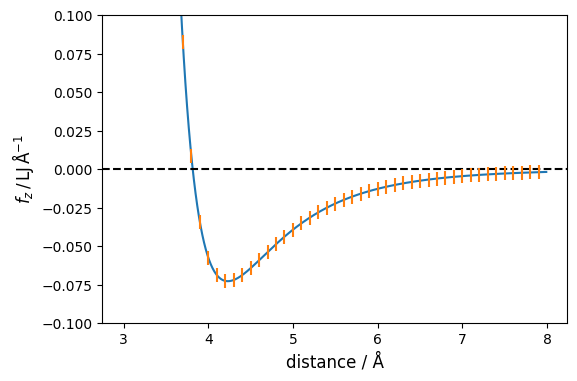

In [14]:
import numpy as np
import ase.io
from ase.calculators.lj import LennardJones

# example adapted from the ASE documentation
Ls = np.arange(3.0, 8.0, 0.01)
plot_list = []

ar2_trajectory = ase.io.Trajectory(output_path / "lj_sweep.traj", "w")
for l in Ls:
    atoms = Atoms('Ar2',
                  positions=[[0., 0., 0.],
                             [0., 0., l]],
                  pbc=False)
    atoms.calc = LennardJones(sigma=3.4, epsilon=0.10323)  # epsilon x10 for visualization

    plot_list.append(atoms.get_forces()[1, 2])
    ar2_trajectory.write(atoms)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Ls, plot_list, c="C0", zorder=0)
nth = 10  # every nth point is plotted on top of the curve
ax.scatter(Ls[::nth], plot_list[::nth], c="C1", marker="|", s=100, zorder=100)
ax.axhline(0, c="black", ls="--")

ax.set_xlabel("distance / Å", fontsize=12)
ax.set_ylabel(r"$f_z\,/\,$LJ$\,$Å$^{-1}$", fontsize=12)
ax.set_ylim((-0.1, 0.1))

We can again look at the trajectory.

In [15]:
import ase.io

# the trajectory file can be read from disk
view(ase.io.Trajectory(output_path / "lj_sweep.traj"))

<Popen: returncode: None args: ['/Users/rwanzenboeck/Documents/theochem/work...>

### `ase.constraints`

One often needed and convenient feature auf ASE are [constraints](https://ase-lib.org/ase/constraints.html#module-ase.constraints) that can be put on `Atoms` or properties. Importantly, GPAW uses these constraints, but this is not the case for all DFT codes, so make sure to always check the documentation. Most constraints are straight-forward to use, with some others more intricate. All of them are well documented though.

Here, I will quickly demonstrate `FixAtoms` and hint at `UnitCellFilter`and its derivates for later use.

In [16]:
from ase.atoms import Atoms
from ase.constraints import FixAtoms
from ase.visualize import view

atoms = Atoms(
    'Ar2U',
    positions=[[0., 0., 0.],
               [0., 0., 3.8],
               [2.5, 2.5, 0.],
              ],
    pbc=False
)
print(atoms)
atoms_list = [atoms.copy()]

# fix the positions of all Ar atoms
c = FixAtoms(indices=[atom.index for atom in atoms if atom.symbol == 'Ar'])
atoms.set_constraint(c)
print(atoms)
atoms_list.append(atoms.copy())

atoms.set_constraint(atoms.constraints + [FixAtoms(indices=[2])])
atoms_list.append(atoms.copy())
view(atoms_list)

Atoms(symbols='Ar2U', pbc=False)
Atoms(symbols='Ar2U', pbc=False, constraint=FixAtoms(indices=[0, 1]))


<Popen: returncode: None args: ['/Users/rwanzenboeck/Documents/theochem/work...>

### `ase.units`

From the [ASE documentation](https://ase-lib.org/ase/units.html):

> Physical units are defined in the ase/units.py module. Electron volts (eV), Ångström (Ang), the atomic mass unit and Kelvin are defined as 1.0. Other units are (amongst others) nm, Bohr, Hartree or Ha, kJ, kcal, mol, Rydberg or Ry, second, fs and kB.

If you need to convert units or pass values in specific units, you should find most of the necessary constants there.

In [17]:
import ase.units

# define pressure p in bar
p = 10 * ase.units.bar

# or a time step in femtoseconds
dt = 2.0 * ase.units.fs

### `ase.optimize`

The optimizer is introduced in a separate [notebook](ase_optimize.ipynb).